In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# 1. 데이터 준비
num_classes = 10
input_shape = (28, 28, 1)

**1. Training Set X,Y 설정**

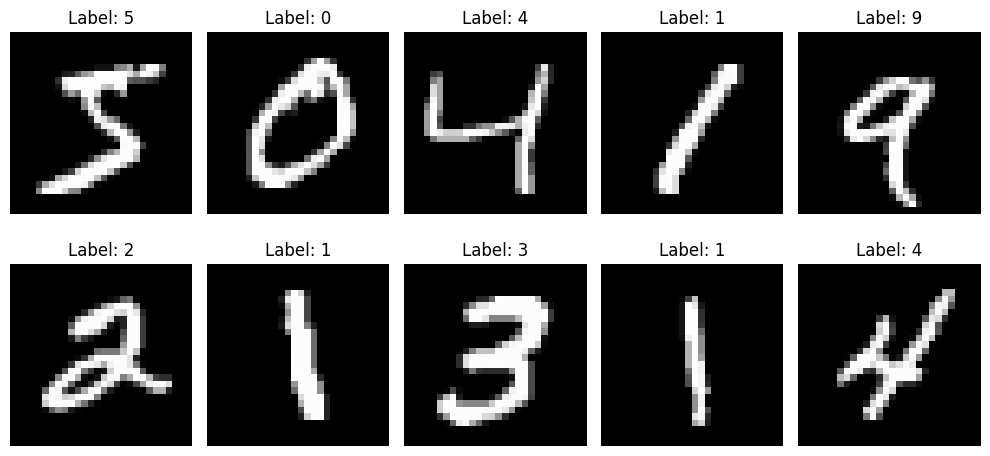

In [5]:
# MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
np.set_printoptions(linewidth=200, threshold=np.inf)
pd.set_option("display.max_columns", 50)   # 기본은 20, 늘려주면 생략 안 됨
pd.set_option("display.width", 300)   
# 처음 10개의 이미지를 화면에 출력하여 확인
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
    # 이미지 픽셀 값을 0 ~ 1 사이로 정규화
    x_train = x_train.astype("float32") / 255
    x_test = x_test.astype("float32") / 255


In [7]:
    # 차원 추가 (샘플 수, 28, 28) -> (샘플 수, 28, 28, 1) CNN는 높이x너비x채널수로 받음, Gray라 채널이 1개
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)

    print("x_train shape:", x_train.shape)
    print(x_train.shape[0], "train samples")
    print(x_test.shape[0], "test samples")

    # 레이블을 원-핫 인코딩(One-hot encoding)으로 변환
    y_train = keras.utils.to_categorical(y_train, num_classes)
    y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


**모델 구성**

In [8]:
    # 2. CNN 모델 구성
    model = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    model.summary()

    # 3. 모델 학습 설정 및 학습 진행
    batch_size = 128
    epochs = 5

    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

**모델 학습**

In [9]:
    print("\n모델 학습을 시작합니다...")
    model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


모델 학습을 시작합니다...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8907 - loss: 0.3580 - val_accuracy: 0.9798 - val_loss: 0.0772
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9671 - loss: 0.1077 - val_accuracy: 0.9835 - val_loss: 0.0582
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9749 - loss: 0.0813 - val_accuracy: 0.9858 - val_loss: 0.0480
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9791 - loss: 0.0682 - val_accuracy: 0.9890 - val_loss: 0.0411
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9821 - loss: 0.0596 - val_accuracy: 0.9900 - val_loss: 0.0372


In [10]:
    # 4. 모델 평가
    score = model.evaluate(x_test, y_test, verbose=0)
    print("\n--- 학습 결과 ---")
    print("Test loss:", score[0])
    print("Test accuracy:", score[1])


--- 학습 결과 ---
Test loss: 0.03442453220486641
Test accuracy: 0.9883999824523926


In [17]:
sample=x_train[0]
sample=np.expand_dims(sample,axis=0)
model.predict(sample)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([[5.5213046e-11, 3.3259392e-10, 1.7890642e-07, 8.9195045e-03, 7.2362173e-12, 9.9107707e-01, 8.8520680e-10, 2.6270965e-07, 2.4117683e-06, 6.0890136e-07]], dtype=float32)

In [18]:
x=np.squeeze(sample)


In [19]:
x.shape


(28, 28)

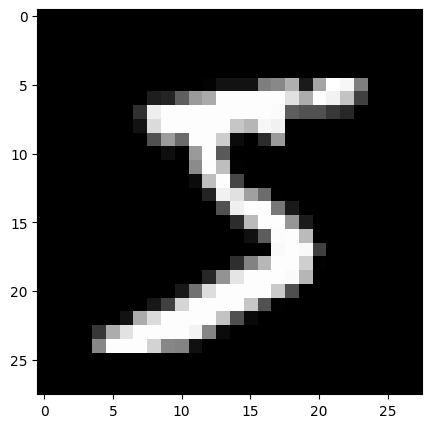

In [20]:
plt.figure(figsize=(10, 5))
plt.imshow(x,cmap='gray')
plt.show()
